In [68]:
import pydytuesday
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
# pydytuesday.get_date('2026-02-24')

In [70]:
# Let's begin by exploring the file itself

df = pd.read_csv("sfi_grants.csv")

print(df.shape)
print(f"These are the dataframe's columns:\n {df.info()}")

print(f"First five rows:\n {df.head()}")

for x in df.columns:
    print(f"\n Value counts for {x}:\n")
    print(df[x].value_counts())


(7269, 12)
<class 'pandas.DataFrame'>
RangeIndex: 7269 entries, 0 to 7268
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   start_date                   7269 non-null   str    
 1   end_date                     7269 non-null   str    
 2   proposal_id                  7269 non-null   str    
 3   programme_name               7261 non-null   str    
 4   sub_programme                2768 non-null   str    
 5   supplement                   1424 non-null   str    
 6   research_body                7269 non-null   str    
 7   research_body_ror_id         6935 non-null   str    
 8   funder_name                  7269 non-null   str    
 9   crossref_funder_registry_id  7269 non-null   str    
 10  proposal_title               7267 non-null   str    
 11  current_total_commitment     7269 non-null   float64
dtypes: float64(1), str(11)
memory usage: 681.6 KB
These are the dataframe's colu

In [71]:
# Now, we can look into the nulls and the incorrect dtypes in the data

to_be_date = ["start_date", "end_date"]
to_be_str = ["proposal_id"]
to_be_float = ["current_total_commitment"]

not_category = to_be_date + to_be_str + to_be_float
to_be_cat = [n for n in df.columns if n not in not_category]

print(to_be_cat)

for x in to_be_date:
    df[x] = pd.to_datetime(df[x])
    
for x in to_be_cat:
    df[x] = df[x].astype("category")
    
# Extracting the year

df["start_year"] = df["start_date"].dt.year
df["end_year"] = df["end_date"].dt.year


print(df.info())


['programme_name', 'sub_programme', 'supplement', 'research_body', 'research_body_ror_id', 'funder_name', 'crossref_funder_registry_id', 'proposal_title']
<class 'pandas.DataFrame'>
RangeIndex: 7269 entries, 0 to 7268
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   start_date                   7269 non-null   datetime64[us]
 1   end_date                     7269 non-null   datetime64[us]
 2   proposal_id                  7269 non-null   str           
 3   programme_name               7261 non-null   category      
 4   sub_programme                2768 non-null   category      
 5   supplement                   1424 non-null   category      
 6   research_body                7269 non-null   category      
 7   research_body_ror_id         6935 non-null   category      
 8   funder_name                  7269 non-null   category      
 9   crossref_funder_registry_id  

In [72]:
# Let's find NAs

for x in df.columns:
    print(f"Column {x}:\n {df[x].isna().sum()}")

Column start_date:
 0
Column end_date:
 0
Column proposal_id:
 0
Column programme_name:
 8
Column sub_programme:
 4501
Column supplement:
 5845
Column research_body:
 0
Column research_body_ror_id:
 334
Column funder_name:
 0
Column crossref_funder_registry_id:
 0
Column proposal_title:
 2
Column current_total_commitment:
 0
Column start_year:
 0
Column end_year:
 0


I need to investigate the four locations of missing values in this data:
1. Programme Name: I will use the proposal id's of these rows try to use the ROR IDs (if any) to find the proper proposal names for these programmes
2. Sub Programme Name: Not all programmes will have (or are) sub programmes, and I need to replace the missing values with "None"
3. Supplement: Only a few programmes got supplementary grants. The rest have to be 'None'.
4. Research Body ROR ID: Not all of the research bodies have this probably because they might be in the process of getting theirs. If it is absolutely important, I can pass their research body names to the ROR API to get their IDs if they actually exist.
5. Proposal Title: For those two rows, I can use their proposal ids to substitute.

In [73]:
# Find missing programme names

print(df.loc[df["programme_name"].isna(), ["proposal_id", "proposal_title"]])

          proposal_id                                     proposal_title
5884      19/FFP/6499  Exploring miR-21 in the dialogue between the m...
6131    20/FFP-P/8818                  RobuSTests: Robust Software Tests
6184    20/FFP-P/8856  Catalytic Wittig CO2 Utilisation Methodology f...
6341   21/PATH-S/9515  Herd Health: The pathogen and health consequen...
6391   21/PATH-S/9320  Extracellular vesicles in Non-Small-Cell Lung ...
6392   21/PATH-S/9360  Probing the evolution of cosmic dust in the ic...
6492    21/FFP-A/9153  Bioprospecting of novel marine terpenoids with...
6882  22/PATH-S/10902  Template Assisted Crystallisation of Oligonucl...


In [74]:
# Find number of institutions receiving grants
# and number of programmes grants are given to

print(df["programme_name"].nunique())

print(df["research_body"].nunique())

66
139


In [75]:
# Now, we can do some EDA
# Let's group by programme_name and sub_programme and find the average amount of spending (commitment)

print(
    df.groupby(["programme_name", "sub_programme"])["current_total_commitment"].mean().nlargest(10)
)
print(
    df.groupby("programme_name")["current_total_commitment"].mean().nlargest(10)
)



print(df["programme_name"].value_counts())

programme_name                                            sub_programme                            
Research Centres Programme                                Phase 2                                      3.529358e+07
Centres for Science Engineering and Technology Programme  Systems Biology                              1.851187e+07
                                                          2nd Term Funding                             1.575801e+07
                                                          Building Grant                               1.091241e+07
Infrastructural Support                                   The Irish Research e-Library Initiative      1.081250e+07
                                                          Tyndall Capital                              1.043375e+07
Research Professorship Programme                          Second-Term Funding                          7.105031e+06
                                                          Targeted Research Professorshi

In [76]:
print(df.groupby(["start_year"])["current_total_commitment"].nlargest(10))

start_year      
2001        10      8287672.71
            9       8240514.66
            1       8069351.70
            3       7939335.11
            6       7785757.07
                       ...    
2024        7062    5542951.00
            7032    4218015.00
            7034    3285362.00
            7225    2767961.00
2025        7268     746752.31
Name: current_total_commitment, Length: 241, dtype: float64


In [77]:
top_grants_per_year = (df.sort_values(by = "current_total_commitment", ascending = False)
						.groupby("start_year")
                        .head(10))

print(top_grants_per_year[["start_year", "programme_name", "current_total_commitment"]].sort_values(by = ["start_year", "current_total_commitment"], ascending = [True, False]))

      start_year                                programme_name  \
10          2001              Principal Investigator Programme   
9           2001              Principal Investigator Programme   
1           2001              Principal Investigator Programme   
3           2001              Principal Investigator Programme   
6           2001              Principal Investigator Programme   
...          ...                                           ...   
7062        2024              Research Professorship Programme   
7032        2024             Research Infrastructure Programme   
7034        2024             Research Infrastructure Programme   
7225        2024               Strategic Partnership Programme   
7268        2025  Royal Society University Research Fellowship   

      current_total_commitment  
10                  8287672.71  
9                   8240514.66  
1                   8069351.70  
3                   7939335.11  
6                   7785757.07  
...      

In [78]:
# What i want is to sum the total grants received by a university in a year

print(top_grants_per_year[["start_year", "research_body", "current_total_commitment"]].sort_values(by = ["start_year", "current_total_commitment"], ascending = [True, False]))

      start_year                                      research_body  \
10          2001                       Trinity College Dublin (TCD)   
9           2001                      University College Cork (UCC)   
1           2001                       Trinity College Dublin (TCD)   
3           2001                           Maynooth University (MU)   
6           2001                       Trinity College Dublin (TCD)   
...          ...                                                ...   
7062        2024                       Dublin City University (DCU)   
7032        2024                      University College Cork (UCC)   
7034        2024                   Tyndall National Institute (TNI)   
7225        2024  RCSI University of Medicine and Health Science...   
7268        2025                          The Royal Society - Grant   

      current_total_commitment  
10                  8287672.71  
9                   8240514.66  
1                   8069351.70  
3              

In [79]:
"""
I want to rank the burn rates of each programme
by calculating the duration of each programme's grant
and using that number to divide its total grant received.
This will give us the "per day" grant amount for each programme.
"""

# Calculating duration (end date - start date)

df["duration"] = df["end_date"] - df["start_date"]

print(df["duration"].head())

df["duration_int"] = df["duration"].dt.days.astype("int")

print(df["duration_int"])

0   2007 days
1   1890 days
2   1890 days
3   1980 days
4   1800 days
Name: duration, dtype: timedelta64[us]
0       2007
1       1890
2       1890
3       1980
4       1800
        ... 
7264    1094
7265    1460
7266    1460
7267    1460
7268    1095
Name: duration_int, Length: 7269, dtype: int64


In [80]:
# Grouping by programme to calculate total grant and total duration

burn_rate_df = df.groupby("programme_name")[["current_total_commitment", "duration_int"]].sum()

burn_rate_df["burn_rate"] = burn_rate_df["current_total_commitment"] / burn_rate_df["duration_int"]

print(burn_rate_df.head(10).sort_values("burn_rate", ascending = False))



                                                    current_total_commitment  \
programme_name                                                                 
Co-Centre Programme                                             3.412490e+07   
Centres for Science Engineering and Technology ...              3.131217e+08   
Centres for Research Training (CRT) Programme                   1.035834e+08   
Charles Parsons Energy Research Awards                          1.177015e+07   
COVID-19 Rapid Response Programme                               1.703486e+07   
Career Development Award                                        4.104957e+07   
BBSRC Joint Funding Programme                                   6.542039e+06   
China / Ireland Science & Technology Collaborat...              7.000000e+05   
Advance Award                                                   1.639613e+06   
Conferences and Workshops Programme                             7.178232e+06   

                                       

In [81]:
# cost_per_day = df.

print(len(burn_rate_df))

66


## Creating plot

In [82]:
from pyfonts import load_google_font

jost_font = load_google_font("Jost")
jost_font_bold = load_google_font("Jost", "bold")

In [90]:
ordered_burn_rate = burn_rate_df.sort_values("burn_rate", ascending = False)
ordered_burn_rate = ordered_burn_rate.reset_index()
print(ordered_burn_rate.head())
my_range = range(1, len(ordered_burn_rate) + 1)

                                      programme_name  \
0                                Co-Centre Programme   
1  Centres for Science Engineering and Technology...   
2                         Research Centres Programme   
3      Centres for Research Training (CRT) Programme   
4                            Infrastructural Support   

   current_total_commitment  duration_int    burn_rate  
0              3.412490e+07          4382  7787.516887  
1              3.131217e+08         40712  7691.139977  
2              9.906864e+08        130125  7613.344143  
3              1.035834e+08         18141  5709.906014  
4              9.542833e+07         17751  5375.940826  


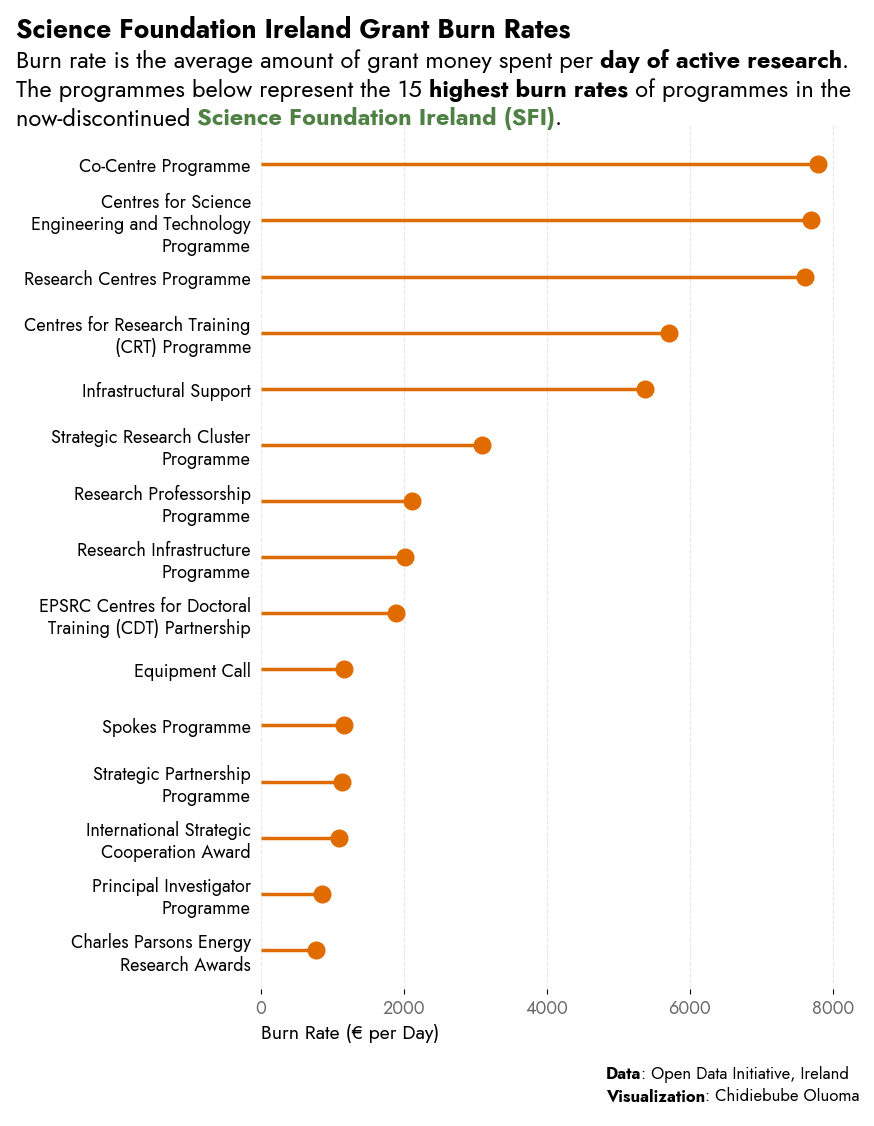

In [184]:
# If I still remember how to plot...
import matplotlib.ticker as ticker
from highlight_text import fig_text
import textwrap

top_15 = ordered_burn_rate.head(15)

top_15["programme_name"] = top_15["programme_name"].apply(lambda x: textwrap.fill(x, width=30))

plot_title = "Science Foundation Ireland Grant Burn Rates"

plot_description = """
Burn rate is the average amount of grant money spent per <day of active research>. 
The programmes below represent the 15 <highest burn rates> of programmes in the 
now-discontinued <Science Foundation Ireland (SFI)>.
"""

credit_text = """
<Data>: Open Data Initiative, Ireland
<Visualization>: Chidiebube Oluoma
"""

fig, ax = plt.subplots(figsize = (10, 12))

fig.subplots_adjust(top=0.82, bottom=0.1, left = 0.315)

ax.hlines(y = top_15["programme_name"],
          xmin = 0,
          xmax = top_15["burn_rate"],
          colors="#E06C00",
          linewidth = 2.5)
ax.plot(top_15["burn_rate"],
        top_15["programme_name"],
        "o",
        color = "#E06C00",
        markersize = 12)
ax.set_xlim(left = 0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# ax.spines['left'].set_color('dimgray')

ax.xaxis.set_major_locator(ticker.MultipleLocator(2000))

ax.invert_yaxis()

ax.set_xlabel("Burn Rate (€ per Day)", fontproperties = jost_font, fontsize = 14, loc = "left")
# ax.set_title("SFI Grant Burn Rate by Programme")

for label in ax.get_yticklabels():
    label.set_fontproperties(jost_font)
    label.set_fontsize(13)
    # label.set_color("dimgray")

for label in ax.get_xticklabels():
    label.set_fontproperties(jost_font)
    label.set_fontsize(13)
    label.set_color("dimgray")

ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
ax.tick_params(axis = "y", which = "both", left = False)

fig_text(
    0.07, 0.85, plot_description,
    ha='left', va='center',
    fontsize=17,
    color='black',
    fontproperties = jost_font,
    highlight_textprops=[
        # {"fontproperties": jost_font_bold},
        {"fontproperties": jost_font_bold},
        {"fontproperties": jost_font_bold},
        {"fontproperties": jost_font_bold, "color": "#508144"},
    ]
)

fig_text(
    0.07, 0.9, plot_title,
    ha='left', va='center',
    fontsize=19,
    color='black',
    fontproperties = jost_font_bold,
)

fig_text(
    0.66, 0.02,
    credit_text,
    ha='left', va='center',
    fontsize=12,
    color='black',
    fontproperties = jost_font,
    highlight_textprops=[
        {"fontproperties": jost_font_bold},
        {"fontproperties": jost_font_bold},
    ]
)

# plt.tight_layout()
plt.savefig("sfi_grants.png", bbox_inches = 'tight')
plt.show()